# Supervised Autoencoder for US Firm Characteristics

This notebook tests whether direct return supervision helps an autoencoder extract a useful
one-month cross-sectional signal from firm characteristics.

**Learning objectives**

- Fit a supervised autoencoder through sealed walk-forward folds.
- Compare complete out-of-sample prediction surfaces at physical training checkpoints.
- Trace undertraining and overtraining from model IC into downstream strategy candidates.

**Book reference:** Chapter 14, latent factor models and supervised autoencoders.

**Prerequisites:** `03_financial_features`, `04_evaluation`, and the split contract used by
`05_linear` through `07_tabular_dl`.

In [1]:
"""US firm characteristics supervised autoencoder run via the shared library path."""

import warnings

import matplotlib.pyplot as plt
import polars as pl
from IPython.display import Markdown, display

from case_studies.utils import registry
from case_studies.utils.latent_factors.case_study import (
    configured_models,
    load_case_study_context,
    run_case_study_model,
)
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
N_FACTORS = 5
N_EPOCHS = 50
USE_CACHE = True
FORCE_RETRAIN = False
MAX_FOLDS = 0
MAX_VARIANT_LABELS = -1
USE_MACRO = False
MODEL_NAME = "sae"
SEED = 42

## Load the dated modeling surface

The shared context fixes the feature order, ten expanding-window splits, continuous target, and
explicit CUDA runtime. Persistent firm identifiers keep each company stable across months. The
2016 holdout remains outside training, validation, cache identity, and checkpoint comparison.

In [3]:
set_global_seeds(SEED)
context = load_case_study_context(
    CASE_STUDY_ID,
    primary_label=PRIMARY_LABEL,
    max_symbols=MAX_SYMBOLS,
    max_folds=MAX_FOLDS,
    max_variant_labels=MAX_VARIANT_LABELS,
    use_macro=USE_MACRO,
)
if MODEL_NAME not in configured_models(context):
    raise ValueError(f"{MODEL_NAME!r} is not configured for {CASE_STUDY_ID}")

print(f"Observations: {len(context.dataset):,}")
print(f"Characteristics: {len(context.feature_names)}")
print(f"Walk-forward folds: {len(context.splits)}")
print(f"Runtime: {context.device}, deterministic={context.deterministic_algorithms}")

Observations: 804,530
Characteristics: 57
Walk-forward folds: 10
Runtime: cuda, deterministic=True


## Run or replay walk-forward training

The model emits predictions every five epochs. Each checkpoint combines predictions from the
same physical epoch across all ten folds, creating a complete out-of-sample surface. The runner's
terminal-epoch summary does not remove other checkpoints: every complete surface remains eligible
for model analysis and the signal-stage backtest.

In [4]:
result = run_case_study_model(
    context,
    model_name=MODEL_NAME,
    notebook="08d_supervised_autoencoder",
    n_factors=N_FACTORS,
    n_epochs=N_EPOCHS,
    use_cache=USE_CACHE,
    force_retrain=FORCE_RETRAIN,
)
fold_metrics = result["fold_metrics"][MODEL_NAME]

print(f"Physical checkpoints: {fold_metrics['epoch'].n_unique()}")
print(f"Completed folds: {fold_metrics['fold_id'].n_unique()}")

Latent factor CV: 1 models × 10 folds
Log file: $ML4T_OUTPUT_DIR/us_firm_characteristics/run_log/latent_factors.log
Scoring: dates=rebalance cadence=monthly_month_end step=1 checkpoint_selection=fixed reporting_epoch=last


  sae: loaded exact registry cohort (IC=-0.0594)
  Best: sae (IC=-0.0594)
Physical checkpoints: 10
Completed folds: 10


## Confirm the registered checkpoint surface

The registry is the reader-facing source of truth. This query binds the displayed curve to the
single corrected SAE training identity and verifies that no interrupted or legacy identity enters
the comparison.

In [5]:
training_runs = registry.load_training_runs(
    CASE_STUDY_ID,
    family="latent_factors",
    label=context.primary_label,
).filter(
    (pl.col("config_name") == MODEL_NAME) & (pl.col("entry_point") == "08d_supervised_autoencoder")
)
if training_runs.height != 1:
    raise ValueError(f"Expected one complete SAE identity, found {training_runs.height}")
training_hash = training_runs["training_hash"][0]

prediction_sets = registry.load_prediction_sets(
    CASE_STUDY_ID,
    training_hash=training_hash,
    split="validation",
)
prediction_metrics = registry.load_prediction_metrics(CASE_STUDY_ID)

Fold signs and dispersion complement the time-series HAC intervals without changing checkpoint
eligibility or selecting a different epoch inside each fold.

In [6]:
fold_summary = (
    fold_metrics.group_by("epoch")
    .agg(
        pl.col("ic_mean").std().alias("fold_std"),
        (pl.col("ic_mean") > 0).sum().alias("positive_folds"),
    )
    .sort("epoch")
)
checkpoint_summary = (
    prediction_sets.join(prediction_metrics, on="prediction_hash", how="inner")
    .sort("checkpoint_value")
    .select(
        pl.col("checkpoint_value").alias("epoch"),
        "prediction_hash",
        "ic_mean_daily",
        "ic_ci_lo",
        "ic_ci_hi",
        "ic_p_hac",
        "ic_n_days",
    )
    .join(fold_summary, on="epoch", how="left")
)
if checkpoint_summary.height != 10:
    raise ValueError(f"Expected ten complete SAE checkpoints, found {checkpoint_summary.height}")
checkpoint_summary

epoch,prediction_hash,ic_mean_daily,ic_ci_lo,ic_ci_hi,ic_p_hac,ic_n_days,fold_std,positive_folds
i64,str,f64,f64,f64,f64,f64,f64,u32
5,"""15defcd8d44e""",0.029973,0.016977,0.042969,0.000013,110.0,0.023398,10
10,"""be15d014ec5a""",0.057854,0.037087,0.07862,2.3011e-7,110.0,0.034852,10
15,"""4f7eaeb2dff6""",0.061974,0.03548,0.088467,0.00001,110.0,0.039675,10
20,"""7fca688b37aa""",0.059706,0.029584,0.089829,0.00015,110.0,0.042278,10
25,"""bd957bc7a2c2""",0.060751,0.030159,0.091343,0.000146,110.0,0.042463,10
30,"""aaf9247b8825""",0.047472,0.01907,0.075874,0.001254,110.0,0.041379,10
35,"""b858b26628bd""",-0.005694,-0.02651,0.015122,0.588803,110.0,0.0317,5
40,"""73fe34b2fd7f""",-0.053418,-0.076017,-0.030818,0.000008,110.0,0.0353,0
45,"""337877e07851""",-0.059901,-0.085155,-0.034646,0.000008,110.0,0.038603,0


## Direct supervision peaks early, then reverses

The global development maximum uses one epoch across every fold. It is not a fold-by-fold
checkpoint composite. All ten surfaces continue to the strategy stage, where their trading
behavior and selection risk can be compared under one common backtest contract.

In [7]:
selected = checkpoint_summary.sort("ic_mean_daily", descending=True).row(0, named=True)
terminal = checkpoint_summary.sort("epoch").tail(1).row(0, named=True)
selected_epoch = int(selected["epoch"])

lower_error = checkpoint_summary["ic_mean_daily"] - checkpoint_summary["ic_ci_lo"]
upper_error = checkpoint_summary["ic_ci_hi"] - checkpoint_summary["ic_mean_daily"]

The curve marks the global development maximum without suppressing any alternative checkpoint.
Bars show HAC 95% intervals computed from the time-ordered monthly IC series.

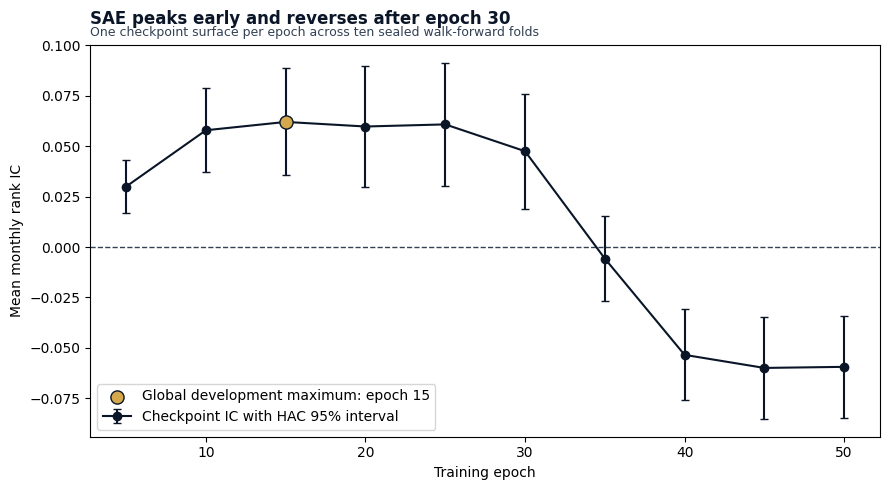

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    checkpoint_summary["epoch"],
    checkpoint_summary["ic_mean_daily"],
    yerr=[lower_error, upper_error],
    color=COLORS["blue"],
    marker="o",
    capsize=3,
    label="Checkpoint IC with HAC 95% interval",
)
ax.scatter(
    [selected_epoch],
    [selected["ic_mean_daily"]],
    color=COLORS["amber"],
    edgecolor=COLORS["blue"],
    s=90,
    zorder=3,
    label=f"Global development maximum: epoch {selected_epoch}",
)
ax.axhline(0, color=COLORS["neutral"], linewidth=1, linestyle="--")
ax.set(xlabel="Training epoch", ylabel="Mean monthly rank IC")
ax.legend(loc="lower left")
add_message_title(
    ax,
    "SAE peaks early and reverses after epoch 30",
    subtitle="One checkpoint surface per epoch across ten sealed walk-forward folds",
)
fig.tight_layout()
fig.show()

## Takeaways

Checkpoint comparison is part of development research. The final holdout remains sealed until the
complete model and strategy funnel selects one carrier.

In [9]:
selected_interval = "excludes" if selected["ic_ci_lo"] * selected["ic_ci_hi"] > 0 else "includes"
display(
    Markdown(
        f"""
- Epoch **{selected_epoch}** is the global development maximum at daily rank IC
  **{selected["ic_mean_daily"]:+.4f}** across **{int(selected["ic_n_days"])}** validation months;
  its HAC 95% interval **[{selected["ic_ci_lo"]:+.4f}, {selected["ic_ci_hi"]:+.4f}]**
  {selected_interval} zero, and all **{int(selected["positive_folds"])}** folds are positive.
- Epochs 10 through 25 form a broad positive plateau. The curve crosses below zero by epoch 35 and
  ends at **{terminal["ic_mean_daily"]:+.4f}**, showing that longer training overfits this monthly
  cross-section.
- Every physical checkpoint remains a distinct prediction candidate for `11_backtest`; no
  fold-specific best-epoch alias enters the registry.
- `08_latent_factors` next compares the eligible latent objectives. Model-family and strategy
  selection occur downstream, and the sealed holdout is opened only for the final carrier.
"""
    )
)


- Epoch **15** is the global development maximum at daily rank IC
  **+0.0620** across **110** validation months;
  its HAC 95% interval **[+0.0355, +0.0885]**
  excludes zero, and all **10** folds are positive.
- Epochs 10 through 25 form a broad positive plateau. The curve crosses below zero by epoch 35 and
  ends at **-0.0594**, showing that longer training overfits this monthly
  cross-section.
- Every physical checkpoint remains a distinct prediction candidate for `11_backtest`; no
  fold-specific best-epoch alias enters the registry.
- `08_latent_factors` next compares the eligible latent objectives. Model-family and strategy
  selection occur downstream, and the sealed holdout is opened only for the final carrier.
